In [ ]:
# Install the latest Google GenAI SDK
!pip install -q -U google-genai

import google.generativeai as genai
from google.colab import userdata

# This pulls your hidden key safely
api_key = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=api_key)

print("Lab is ready! Gemini 3.1 Pro is connected.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.2/732.2 kB 41.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Lab is ready! Gemini 3.1 Pro is connected.


In [ ]:
import sys

# 1. Install the NEW 2026 SDK
!pip install -q -U google-genai

from google import genai
from google.colab import userdata

# 2. Setup the Client using the new SDK
# Ensure your secret name in Colab is 'GOOGLE_API_KEY' as retrieved in the first cell.
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

# 3. Test the connection
response = client.models.generate_content(
    model='gemini-2.5-flash', # Or 'gemini-3.1-pro'
    contents='Tell me one tip for a Data Analyst in Ahmedabad.'
)

print(f"--- 2026 Lab Status: Connected ---\nResponse: {response.text}")

--- 2026 Lab Status: Connected ---
Response: **Deeply understand the unique business challenges and data landscapes within Ahmedabad's key industries.**

This means going beyond generic data analysis skills and actively researching how data is used (or *could* be used) in sectors prominent in Ahmedabad, such as:
*   **Pharmaceuticals:** R&D analytics, supply chain optimization, sales forecasting.
*   **Manufacturing:** Production efficiency, predictive maintenance, quality control.
*   **Textiles:** Demand forecasting, inventory management, supply chain analytics.
*   **Education:** Student performance analysis, course optimization, administrative efficiency.
*   **Local Startups/SMEs:** Customer behavior, market analysis, operational insights for growth.

By tailoring your analytical approach to these specific local contexts, you'll be able to deliver far more impactful and relevant insights, making you an invaluable asset in the Ahmedabad job market.


In [ ]:
import pandas as pd

# We use 'file_path' as a placeholder name inside the function
def sales_copilot_chat(file_path):
    # 1. Load the data using the file_path provided
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)

    # 2. Prepare the context for Gemini
    context = f"Dataset Columns: {df.columns.tolist()}\nFirst 3 rows:\n{df.head(3).to_string()}"

    print(f"🚀 Sales Copilot is analyzing '{file_path}'! Type 'exit' to stop.")

    while True:
        query = input("\nAsk about your data: ")
        if query.lower() in ['exit', 'quit']:
            print("Closing Copilot. Goodbye!")
            break

        # 3. Ask Gemini to analyze the data
        # Note: In 2026, we use 'gemini-2.0-flash' or 'gemini-1.5-pro'
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=f"{context}\n\nUser Question: {query}\n\nProvide a sharp business insight for a BFSI professional."
        )

        print(f"\n💡 Insight: {response.text}\n")

# --- HOW TO RUN IT ---
# Since you uploaded 'bank.csv', just run this line:
sales_copilot_chat('bank.csv')

🚀 Sales Copilot is analyzing 'bank.csv'! Type 'exit' to stop.

Ask about your data: total number of customers

💡 Insight: The total number of customers is equal to the total number of rows in the dataset.

---

### Sharp Business Insight for a BFSI Professional:

This dataset offers a critical opportunity to move beyond spray-and-pray marketing to **hyper-personalized lead prioritization, significantly reducing Customer Acquisition Costs (CAC) and boosting Return on Marketing Investment (ROMI).**

Specifically, by leveraging `poutcome` (outcome of previous campaign) and `previous` (number of previous contacts) in conjunction with `balance`, `housing`, and `loan` status, a BFSI professional can:

1.  **Identify "warm" leads:** Customers with a positive `poutcome` (e.g., "success") from previous campaigns are likely more receptive.
2.  **Filter by financial capacity/need:** Customers with higher `balance` or those without existing `loan`/`housing` commitments might have greater disposabl

In [ ]:
from google import genai
from google.genai import types
import pandas as pd

def visual_sales_copilot(file_path):
    # 1. Load data for context
    df = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)

    # We give Gemini the 'metadata' (columns and types) so it knows what to plot
    data_info = f"Columns: {df.columns.tolist()}\nData Types: {df.dtypes.to_string()}"

    print(f"📊 Visual Copilot is ready for '{file_path}'! Ask for a chart or a calculation.")

    while True:
        query = input("\nWhat should I analyze/plot? ")
        if query.lower() in ['exit', 'quit']: break

        # 2. The 'Magic' - we enable code_execution as a tool
        prompt = f"""
        I have a dataset at '{file_path}'.
        {data_info}

        User Request: {query}

        If the user asks for a chart, write Python code using Matplotlib or Seaborn to create it.
        If the user asks for a calculation, write Python to get the exact number.
        """

        response = client.models.generate_content(
            model='gemini-2.5-flash', # Or 'gemini-1.5-pro'
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(code_execution=types.ToolCodeExecution())]
            )
        )

        # 3. Display the AI's reasoning and the result
        for part in response.candidates[0].content.parts:
            if part.text:
                print(f"\n💡 AI Analysis: {part.text}")
            if part.executable_code:
                print(f"--- AI is running this code internally ---\n{part.executable_code.code}")
            if part.code_execution_result:
                print(f"--- Result ---\n{part.code_execution_result.output}")

# Run it!
visual_sales_copilot('bank.csv')

📊 Visual Copilot is ready for 'bank.csv'! Ask for a chart or a calculation.

What should I analyze/plot? exit


In [ ]:
import pandas as pd
from google import genai
from google.genai import types

def visual_sales_copilot(file_path):
    # 1. Load the data in YOUR Colab first
    df = pd.read_csv(file_path)

    # 2. We take a small 'sample' to show the AI the structure
    # and we convert the WHOLE data to a string for the AI's code to use
    csv_data = df.to_csv(index=False)

    print(f"✅ System Online. Ready to analyze '{file_path}'")

    while True:
        query = input("\nYour Analysis Request: ")
        if query.lower() in ['exit', 'quit']: break

        # 3. We tell the AI: "Here is the data, write code using THIS string"
        prompt = f"""
        You are a Data Analyst. I am providing the dataset as a string below.

        DATASET:
        {csv_data}

        TASK: {query}

        INSTRUCTIONS:
        1. Use 'io.StringIO' to read the DATASET string into a pandas DataFrame named 'df'.
        2. Perform the analysis or create the chart using 'df'.
        3. Use 'plt.show()' to display any charts.
        """

        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(code_execution=types.ToolCodeExecution())]
            )
        )

        for part in response.candidates[0].content.parts:
            if part.text: print(f"\n💡 Insight: {part.text}")
            if part.executable_code: print(f"🛠️ AI Code:\n{part.executable_code.code}")
            if part.code_execution_result: print(f"📈 Result:\n{part.code_execution_result.output}")

visual_sales_copilot('bank.csv')


import io
import pandas as pd
csv_string = "...your actual data here..."
df = pd.read_csv(io.StringIO(csv_string))
# Now it can find 'df' perfectly!


✅ System Online. Ready to analyze 'bank.csv'

Your Analysis Request: chart


KeyboardInterrupt: 

In [ ]:
!pip freeze | grep -E "google-genai|pandas|matplotlib"

geopandas==1.1.2
google-genai==1.66.0
matplotlib==3.10.0
matplotlib-inline==0.2.1
matplotlib-venn==1.1.2
pandas==2.2.2
pandas-datareader==0.10.0
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
sklearn-pandas==2.2.0


In [33]:
import pandas as pd
from google import genai
from google.genai import types

# 1. We only send the COLUMN NAMES and a SAMPLE to the AI
df_sample = pd.read_csv('bank.csv', nrows=5)
column_info = df_sample.to_string()

def analyze_lightweight(query):
    # We tell the AI the file is ALREADY on the disk at 'bank.csv'
    prompt = f"""
    You are a Data Analyst. The dataset is located at 'bank.csv'.
    Here are the first few rows for context:
    {column_info}

    Task: {query}

    Instructions:
    1. Write Python code to read 'bank.csv' using pandas.
    2. Create the chart using Matplotlib/Seaborn.
    3. Use 'plt.show()' to display it.
    """

    try:
        response = client.models.generate_content(
            model='gemini-2.0-flash',
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(code_execution=types.ToolCodeExecution())]
            )
        )

        for part in response.candidates[0].content.parts:
            if part.text: print(f"💡 Insight: {part.text}")
            if part.code_execution_result: print(f"📈 Result:\n{part.code_execution_result.output}")

    except Exception as e:
        print(f"⚠️ Error: {e}")

# Wait 60 seconds before running this to let your quota reset!
# analyze_lightweight("Show me a bar chart of the 'job' column.")

In [39]:
import pandas as pd
from google import genai
from google.genai import types

# 1. Initialize the sample for the AI
df_sample = pd.read_csv('bank.csv', nrows=2)
metadata = f"Columns: {df_sample.columns.tolist()}"

def debug_analyze(query):
    print("🛰️ Step 1: Sending request to Gemini...")

    prompt = f"""
    Context: Dataset 'bank.csv' with {metadata}.
    Task: {query}
    Instructions: Write Python to read 'bank.csv' and use plt.show().
    """

    try:
        response = client.models.generate_content(
            model='gemini-1.5-flash',
            contents=prompt,
            config=types.GenerateContentConfig(
                tools=[types.Tool(code_execution=types.ToolCodeExecution())]
            )
        )

        print("📥 Step 2: Response received. Checking for content...")

        if not response.candidates:
            print("❌ No candidates found in response.")
            return

        # 2. Iterate through parts and FORCE print everything
        for i, part in enumerate(response.candidates[0].content.parts):
            print(f"--- Part {i} ---")
            if part.text:
                print(f"💡 AI TEXT: {part.text}")
            if part.executable_code:
                print(f"🛠️ AI CODE:\n{part.executable_code.code}")
            if part.code_execution_result:
                print(f"📈 EXECUTION RESULT:\n{part.code_execution_result.output}")

        print("✅ Analysis Complete.")

    except Exception as e:
        print(f"❌ SYSTEM ERROR: {e}")

# RUN THIS TEST
debug_analyze("Show a bar chart of the 'deposit' column.")

🛰️ Step 1: Sending request to Gemini...
❌ SYSTEM ERROR: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}


📊 --- BFSI Sales Analysis Dashboard ---


/tmp/ipykernel_723/2245249412.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit', palette='viridis')


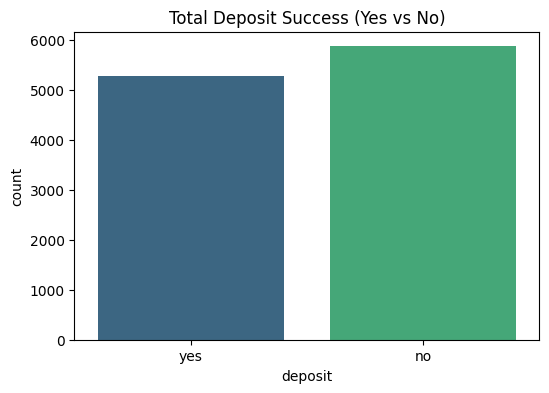

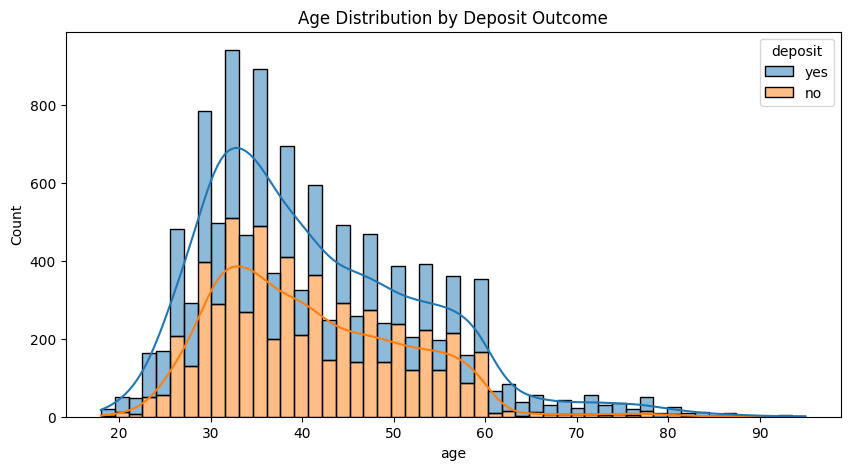

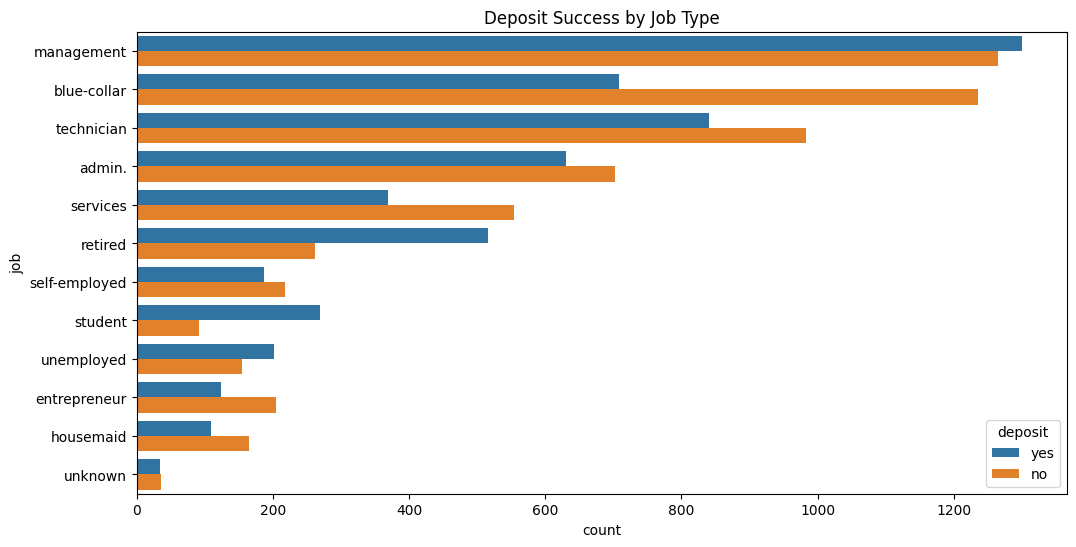

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('bank.csv')

def manual_analysis():
    print("📊 --- BFSI Sales Analysis Dashboard ---")

    # Trend 1: Deposit Success Rate
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='deposit', palette='viridis')
    plt.title('Total Deposit Success (Yes vs No)')
    plt.show()

    # Trend 2: Age vs. Deposit
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='age', hue='deposit', kde=True, multiple='stack')
    plt.title('Age Distribution by Deposit Outcome')
    plt.show()

    # Trend 3: Job Category Success
    plt.figure(figsize=(12, 6))
    job_order = df['job'].value_counts().index
    sns.countplot(data=df, y='job', hue='deposit', order=job_order)
    plt.title('Deposit Success by Job Type')
    plt.show()

manual_analysis()